### Import all required modules

In [14]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import json as js
import os
import pandas as pd
import pyfftw  # FFTW used in Matlab.
from pathlib import Path
from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit
from scipy.special import erf
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

# Constants
c = 299792458  # speed of light in m/s
q = 1.60217646E-19                         # electronic charge
permittivity = 8.854187817620E-12          # permittivity of free space

# Bandwidth range
bandwidth = ()
bandwidth_xlim = (-0.01, 10)
bandwidth_ylim = (2, 1e5)

fontsize = 25
tick_fontsize = 15
figure_size_3 = (10, 13)
figure_size_2 = (18, 6.5)
figure_size_1 = (15, 6.5)

### Reminder of sampling scheme
Sampling scheme is dependent on the frequency at which we chop the THz generation pulse, and the pump pulse. Current default is 2500 Hz and 1250 Hz respectively, but one must always adjust the code accordingly, or better yet, encode it within the experimentation program so ABCD signal would always adhere to the following scheme:

## Pulses schematic
A: E_on + pump + gate pulse <br>
B: Pump + gate pulse        <br>
C: E_off + gate pulse       <br>
D: Gate pulse (balance)

Therefore, to get the relevant information: <br>
**Dark THz signal**:<br>
&nbsp;&nbsp;&nbsp;&nbsp;- *E_off* = (C - D)<br>
**Pump THz signal**:<br>
&nbsp;&nbsp;&nbsp;&nbsp;- *E_on* = (A - B)<br>
**Change in sample properties between excited and unexcited states**:<br>
&nbsp;&nbsp;&nbsp;&nbsp;- *DT* = (A - B) - (C - D)<br>
**Sample THz emission**: <br>
&nbsp;&nbsp;&nbsp;&nbsp;- *sample_emission* = (B - D)



In [15]:
def generate_cleaned_up_dataframe(filepath,
                                  limits: list = [],
                                  zeropad: list = []):
    """
    Automatically reads data files with extension .txt and .hfd5.
    Cleans up the dataframe by sorting the delay.
    Also adds columns for E_on, E_off, Delta_E and their respective FFTs.
    Also adds a column for the frequencies at which the FFTs are taken.
    """
    # TODO: Add file type handling (e.g., .txt, .hdf5)
    if filepath.endswith('.txt'):
        dataframe = pd.read_csv(filepath, sep="	", header=0)
    if limits != []:
        dataframe = dataframe.iloc[limits[0]:limits[0]+limits[1]]
    if zeropad != []:
        dataframe = dataframe.sort_values(by='Delay (mm)')
        delay_before = np.arange(zeropad[0], dataframe['Delay (mm)'].iloc[0], zeropad[2])
        delay_after = np.arange(dataframe['Delay (mm)'].iloc[-1]+zeropad[2],
                                zeropad[1]+zeropad[2], zeropad[2])
        padding_dict_before = {"Delay (mm)": delay_before,
                               "A": [0]*len(delay_before), "B": [0]*len(delay_before),
                               "C": [0]*len(delay_before), "D": [0]*len(delay_before),
                               "Background noise": [0]*len(delay_before),
                               "Emitter noise": [0]*len(delay_before),
                               "Pump-induced noise": [0]*len(delay_before),
                               "Total noise": [0]*len(delay_before), "OPTP noise": [0]*len(delay_before),
                               "Saturation": [False]*len(delay_before)}
        padding_dict_after = {"Delay (mm)": delay_after,
                               "A": [0]*len(delay_after), "B": [0]*len(delay_after),
                               "C": [0]*len(delay_after), "D": [0]*len(delay_after),
                               "Background noise": [0]*len(delay_after),
                               "Emitter noise": [0]*len(delay_after),
                               "Pump-induced noise": [0]*len(delay_after),
                               "Total noise": [0]*len(delay_after), "OPTP noise": [0]*len(delay_after),
                               "Saturation": [False]*len(delay_after)}
        zero_padding_before = pd.DataFrame(padding_dict_before)
        zero_padding_after = pd.DataFrame(padding_dict_after)
        dataframe = pd.concat([zero_padding_before, dataframe, zero_padding_after], ignore_index=True)
    dataframe = dataframe.sort_values(by='Delay (mm)')
    dataframe.reset_index(drop=True, inplace=True)

    # convert position of delay stage to time delay (in seconds)
    dataframe.insert(1, 'Delay (s)', dataframe['Delay (mm)']*((2E-3)/c))
    
    # Get E on, E off, Delta E and their respective FFTs
    dataframe.insert(2, 'E_off', dataframe['C'] - dataframe['D'])
    dataframe.insert(3, 'fft_E_off', fft(dataframe['E_off']))
    dataframe.insert(4, 'fft_E_off_dB', 20 * np.log10(dataframe['fft_E_off'].abs()))
    dataframe.insert(5, 'E_on', dataframe['A'] - dataframe['B'])
    dataframe.insert(6, 'fft_E_on', fft(dataframe['E_on']))
    dataframe.insert(7, 'fft_E_on_dB', 20 * np.log10(dataframe['fft_E_on'].abs()))
    dataframe.insert(8, 'Delta_E', dataframe['E_on'] - dataframe['E_off'])
    dataframe.insert(9, 'fft_Delta_E', fft(dataframe['Delta_E']))
    dataframe.insert(10, 'fft_Delta_E_dB', 20 * np.log10(dataframe['fft_Delta_E'].abs()))

    # calculate the frequencies, f, at which the fft is taken
    num_data_points = len(dataframe)
    double_bandwidth = num_data_points/(dataframe['Delay (s)'].iloc[-1] -
                                        dataframe['Delay (s)'].iloc[0])
    dataframe.insert(2, 'Frequencies (Hz)', np.linspace(0, double_bandwidth, num_data_points))

    return dataframe

# Example usage
generate_cleaned_up_dataframe("D:/Aldric/Data/250822/1_vacuum_pumped_Dark THz.txt", limits= [10, 200],
                              zeropad=[35, 36.6, 0.05])

,Delay (mm),Delay (s),Frequencies (Hz),E_off,fft_E_off,fft_E_off_dB,E_on,fft_E_on,fft_E_on_dB,Delta_E,...,A,B,C,D,Background noise,Emitter noise,Pump-induced noise,Total noise,OPTP noise,Saturation
0,35.000000,2.334949e-10,0.000000e+00,0.000000,-67.147750- 0.000000j,36.540629,0.000000,-20.048500- 0.000000j,26.041638,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False
1,35.050000,2.338284e-10,9.290467e+10,0.000000,-39.336142-30.814140j,33.973913,0.000000,-50.514857-60.655848j,37.945496,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False
2,35.075188,2.339965e-10,1.858093e+11,-0.751750,-87.026543-79.864011j,41.446327,0.948000,-91.718052-47.248894j,40.271318,1.699750,...,-4.017167,-4.965167,-6.144333,-5.392583,15.411022,9.363777,14.360125,13.807429,17.722315,NaN
3,35.082707,2.340466e-10,2.787140e+11,-1.177333,-49.920649+ 0.277043j,33.965738,0.359917,23.435639- 5.347376j,27.617953,1.537250,...,-10.073333,-10.433250,-12.902083,-11.724750,13.271744,8.294570,14.211546,13.831347,15.774967,NaN
4,35.090226,2.340968e-10,3.716187e+11,-1.377583,5.981220-43.146688j,32.781616,1.307000,-4.169848-13.612063j,23.068021,2.684583,...,-3.486000,-4.793000,-5.268083,-3.890500,19.174712,11.681024,13.994422,12.802327,18.948540,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,36.548872,2.438278e-10,1.839513e+13,-2.644083,5.996081-50.866327j,34.188539,-4.338417,13.893103-27.456360j,29.762904,-1.694333,...,-12.199583,-7.861167,-11.968917,-9.324833,21.804490,12.069031,11.824769,12.994091,17.780479,NaN
199,36.556391,2.438780e-10,1.848803e+13,-4.834917,5.981220+43.146688j,32.781616,-1.486667,-4.169848+13.612063j,23.068021,3.348250,...,10.610333,12.097000,10.961750,15.796667,15.706217,14.224696,13.958568,14.254336,17.141405,NaN
200,36.563910,2.439281e-10,1.858093e+13,-1.562667,-49.920649- 0.277043j,33.965738,-3.698750,23.435639+ 5.347376j,27.617953,-2.136083,...,7.642000,11.340750,10.067500,11.630167,16.257922,12.079689,10.815283,13.325545,18.275099,NaN
201,36.571429,2.439783e-10,1.867384e+13,-3.395250,-87.026543+79.864011j,41.446327,-2.358917,-91.718052+47.248894j,40.271318,1.036333,...,0.130667,2.489583,-0.717417,2.677833,11.297316,9.312701,14.353102,14.334027,16.527117,NaN


# Useful plotting functions

In [4]:
def annotate_subplots(subplot_list, fontsize=tick_fontsize,
                      annotation_fontsize=fontsize):
    labels = ('a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)',
              'l)', 'm)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)', 't', 'u)', 'v',
              'w)', 'x)', 'y)', 'z)')
    num = 0
    for subplot in subplot_list:
        # Use Axes.annotate to put the label
        # - at the top left corner (axes fraction (0, 1)),
        # - offset half-a-fontsize right and half-a-fontsize down
        #   (offset fontsize (+0.5, -0.5)),
        # i.e. just inside the axes.
        subplot.annotate(
            labels[num],
            xy=(0, 1), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',
            fontsize=annotation_fontsize, verticalalignment='top')
        subplot.tick_params(axis='both', which='major', labelsize=fontsize)
        num = num + 1


def xy_line_markers(subplot,
                    x_value,
                    y_value,
                    x_min=0,
                    y_min=0,
                    line_style='dashed',
                    line_colour='r',
                    plot_h_line=True,
                    plot_v_line=True):
    if plot_h_line:
        if x_value > x_min:
            subplot.hlines(y=y_value, xmin=x_min, xmax=x_value,
                        linestyles=line_style, color=line_colour)
        elif x_value < x_min:
            subplot.hlines(y=y_value, xmin=x_value, xmax=x_min,
                        linestyles=line_style, color=line_colour)
    if plot_v_line:
        if y_value > y_min:
            subplot.vlines(x=x_value, ymin=y_min, ymax=y_value,
                           linestyles=line_style, color=line_colour)
        elif y_value < y_min:
            subplot.vlines(x=x_value, ymin=y_value, ymax=y_min,
                           linestyles=line_style, color=line_colour)


def create_folder(name):
    if not os.path.exists(name):
        os.makedirs(name)
        print(f"{name} created!")
    else:
        print(f"{name} exists!")


def fig_save(filename):
    increments = 1
    if os.path.exists(f'{filename}.png'):
        print(filename)
        while os.path.exists(f'{filename} ({increments}).png'):
            increments += 1
        plt.savefig(f'{filename} ({increments}).png')
        print('WARNING: Figures were duplicated!')
    else:
        plt.savefig(f'{filename}.png')

In [21]:
def extract_bandwidth(dataframe, print_details=True):
    max_fft_E_off = dataframe[(dataframe['Frequencies (Hz)'] * 1e-12 < 10)]['fft_E_off'].abs().max()
    max_fft_E_off_index = dataframe.index[(dataframe['fft_E_off'].abs() == max_fft_E_off)][0]
    
    bandwidth_lower_cond = ((dataframe['fft_E_off'].abs() < max_fft_E_off/10) &
                            (dataframe['Frequencies (Hz)'] * 1e-12 >
                             bandwidth_xlim[0]) &
                            (dataframe['Frequencies (Hz)'] * 1e-12 <
                             dataframe['Frequencies (Hz)']
                             [max_fft_E_off_index] * 1e-12))
    bandwidth_upper_cond = ((dataframe['fft_E_off'].abs() >= max_fft_E_off/10) &
                            (dataframe['Frequencies (Hz)'] * 1e-12 <
                             bandwidth_xlim[1]) &
                            (dataframe['Frequencies (Hz)'] * 1e-12 >
                             dataframe['Frequencies (Hz)']
                             [max_fft_E_off_index] * 1e-12))
    if any(dataframe.index[bandwidth_lower_cond]):
        BW_lower_index = dataframe.index[bandwidth_lower_cond][0]+1
    else:
        BW_lower_index = 0
    BW_index = list(dataframe.index[bandwidth_upper_cond])
    BW_upper_index = [BW_index[i] for i in range(len(BW_index))
                        if ((BW_index[i] - BW_index[i-1]) == 1)][-1]
    BW_lower = round(dataframe['Frequencies (Hz)'][BW_lower_index] * 1e-12, 3)
    BW_upper = round(dataframe['Frequencies (Hz)'][BW_upper_index] * 1e-12, 3)
    bandwidth = round((dataframe['Frequencies (Hz)'][BW_upper_index] -
                        dataframe['Frequencies (Hz)'][BW_lower_index]) * 1e-12, 3)
    if print_details:
        print('fft_E max at = ', dataframe['Frequencies (Hz)'][max_fft_E_off_index] * 1e-12)
        print(max_fft_E_off_index)
        print('Bandwidth lower limit = ', BW_lower, ' THz')
        print('Bandwidth upper limit = ', BW_upper, ' THz')
        print('Bandwidth = ', round(bandwidth, 3), ' THz')

    return BW_lower_index, max_fft_E_off_index, BW_upper_index, bandwidth

def plot_dark_spectrum(dark_axs,
                       dataframe,
                       label = None,
                       color = 'black',
                       plot_noise = True,
                       **kwargs):
    """
    Plots the time and frequency domain of dark THz from the dataframe.
    Can pass upper and lower bandwidth indexes as kwargs to highlight them.
    Can also pass dB=True to change y-axis to dB scale.
    Can also pass if SNR data are to be plotted instead.
    """
    dark_axs[0].plot(dataframe['Delay (s)'] * 1e12, dataframe['E_off'],
                         color=color, label=label)
    dark_axs[1].plot(dataframe['Frequencies (Hz)'] * 1e-12,
                    dataframe['fft_E_off_dB'] - dataframe['fft_E_off_dB'].max(),
                    color=color, label=label)
    # dark_axs[1].semilogy(dataframe['Frequencies (Hz)'] * 1e-12,
    #                      dataframe['fft_E_off'].abs(),
    #                      color=color, label=label)
    # dark_axs[1].fill_between(dataframe['Frequencies (Hz)'] * 1e-12,
    #                 20 * np.log10(dataframe['fft_E_off'].abs())-(20 * np.log10(dataframe['fft_E_off'].abs())).max(),
    #                 color='green', alpha=0.3)
    
    if kwargs.get('plot_balance') is not None and kwargs.get('plot_balance') is True:
        dark_axs[0].plot(dataframe['Delay (s)'] * 1e12, dataframe['D'],
                            color=color, alpha=0.3, linestyle='--', label=f'{label} balance')

    if plot_noise == True:
        noise_level = 20*np.log10(abs(pyfftw.builders.fft(dataframe['Emitter noise'])()))
        noise_level = noise_level - noise_level.max()
        dark_axs[1].plot(dataframe['Frequencies (Hz)'] * 1e-12,
                    noise_level,
                    color=color, alpha=0.3, linestyle='--', label=f'{label} noise')

    if (kwargs.get('BW_lower_index') is not None and
        kwargs.get('BW_upper_index') is not None):
        BW_lower_index = kwargs.get('BW_lower_index')
        BW_upper_index = kwargs.get('BW_upper_index')
        xy_line_markers(dark_axs[1],
                        dataframe['Frequencies (Hz)'][BW_lower_index] * 1e-12,
                        -20, y_min=bandwidth_ylim[0],
                        plot_h_line=False, line_colour=color)
        xy_line_markers(dark_axs[1],
                        dataframe['Frequencies (Hz)'][BW_upper_index] * 1e-12,
                        -20, y_min=bandwidth_ylim[0], plot_h_line=False, line_colour=color)
    dark_axs[1].set_xlim(bandwidth_xlim[0], bandwidth_xlim[1])
    # dark_axs[1].set_ylim(bandwidth_ylim[0], bandwidth_ylim[1])
    dark_axs[1].grid(color='black', which="both", linestyle='--',
                    linewidth=0.3)

    dark_axs[0].set_ylabel(r'$E^{\mathrm{OFF}}(t)$ (a.u.)',
                            fontsize=fontsize)
    dark_axs[1].set_ylabel(r'$|E^{\mathrm{OFF}}(\omega)|$ (dB)',
                            fontsize=fontsize)
    dark_axs[0].set_xlabel(r'THz delay, t (ps)', fontsize=fontsize)
    dark_axs[1].set_xlabel(r'Frequency (THz)', fontsize=fontsize)

    if kwargs.get('legend') is not None:
        dark_axs[0].legend(fontsize=tick_fontsize)
        dark_axs[1].legend(fontsize=tick_fontsize)

    annotate_subplots(dark_axs)

    return dark_axs

# Spot size function from knife edge method

In [6]:
def knife_edge_erf(x, amplitude, center, width, offset):
    """
    Model for the transmitted power from a knife-edge scan of a Gaussian beam.
    
    Parameters:
    - x (array): Position of the knife edge.
    - amplitude (float): Total power transmitted when the beam is unobstructed.
    - center (float): The x-position of the beam's center.
    - width (float): The width of the Gaussian beam (related to its standard deviation).
    - offset (float): The power offset (e.g., background light).
    
    The error function `erf` is defined as the integral of a Gaussian.
    The knife-edge scan measures the integral of the beam's intensity, so it follows an erf curve.
    """
    return (amplitude / 2) * (1 - erf((x - center) / (np.sqrt(2) * width))) + offset

def gaussian(x, amplitude, center, width):
    """
    Standard Gaussian function.
    """
    return amplitude * np.exp(-((x - center) ** 2) / (2 * width ** 2))

def findBeamWidth(data):
    """ 
    This function finds the beam width from the given 1D data.
    """
    df = pd.DataFrame(data)
    x = df["x"]
    amplitude = np.abs(df["Amplitude"])
    amplitude_gradient = np.abs(np.gradient(amplitude))
    max_gradient_position = np.argmax(amplitude_gradient)

    initial_guess = [np.max(amplitude)-np.min(amplitude),   # Amplitude
                     x[max_gradient_position],              # Center position
                     0.5,                                   # Width   
                     np.min(amplitude)]                     # Offset  

    popt, pcov = curve_fit(knife_edge_erf, x, amplitude, p0=initial_guess)
    fit_amplitude, fit_center, fit_width_sigma, fit_offset = popt

    beam_radius_1e2 = 2 * fit_width_sigma
    max_intensity = fit_amplitude / (np.sqrt(2 * np.pi) * fit_width_sigma)
    y_gaussian = gaussian(x, fit_amplitude /
                          (np.sqrt(2 * np.pi) * fit_width_sigma),
                          fit_center,
                          fit_width_sigma)

    result = {"x": x, "amplitude": amplitude, "y_gaussian": y_gaussian,
              "popt": popt, "max_intensity": max_intensity, "fit_amplitude": fit_amplitude,
              "fit_center": fit_center, "fit_width_sigma": fit_width_sigma, "fit_offset": fit_offset,
              "beam_radius_1e2": beam_radius_1e2}

    return result

def analyze_beam(filename, plot=True, visualise_focal_1D = False):
    """
    Analyze knife-edge scans to extract beam centers and 1/e^2 radii.
    """
    # Load data from JSON file
    with open(filename, "r") as f:
        data_dict = js.load(f)

    # Convert keys to floats and sort by y
    y_values = sorted([float(y) for y in data_dict.keys()])
    
    centers = []
    radii = []
    
    # Build 2D amplitude map
    X, Y, Z = [], [], []
    
    for y in y_values:
        result = findBeamWidth(data_dict[str(y)])
        centers.append(result["fit_center"])
        radii.append(result["beam_radius_1e2"])

        X.extend(result["x"])
        Y.extend([y] * len(result["x"]))
        Z.extend(result["y_gaussian"])
    
    centers = np.array(centers)
    radii = np.array(radii)

    # Find focal point (smallest radius)
    focal_y = y_values[np.nanargmin(radii)]

    if plot:
        # Heatmap via tricontourf (since grid may be irregular)
        plt.figure(figsize=(8,6))
        sc = plt.tricontourf(X, Y, Z, levels=100, cmap="inferno")
        plt.colorbar(sc, label="Amplitude")

        # Overlay beam centers and radii
        plt.plot(centers, y_values, "c.-", label="Beam center")
        plt.plot(centers - radii, y_values, "g--", label="1/e² radius edge")
        plt.plot(centers + radii, y_values, "g--")
        plt.axhline(focal_y, color="blue", linestyle=":", label="Focal plane")

        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.title("Beam Profile and 1/e² Radius")
        plt.show()
    
    if visualise_focal_1D:
        focal_data = findBeamWidth(data_dict[str(focal_y)])
        visualise_1D_gaussian_beam_profile(focal_data)

    return focal_y

def visualise_1D_gaussian_beam_profile(input_dict):
    print(f"Fitted amplitude: {input_dict['fit_amplitude']:.4f}")
    print(f"Fitted center: {input_dict['fit_center']:.4f}")
    print(f"Fitted Gaussian width (sigma): {input_dict['fit_width_sigma']:.4f}")
    print(f"Fitted offset: {input_dict['fit_offset']:.4f}")

    plt.figure(figsize=(10, 6))
    plt.scatter(input_dict['x'], input_dict['amplitude'], label="Raw Knife-Edge Data", color='gray')
    plt.plot(input_dict['x'], knife_edge_erf(input_dict['x'], *input_dict['popt']), label="Fitted Error Function", color='red', lw=2)
    plt.plot(input_dict['x'], input_dict['y_gaussian'], label="Reconstructed Gaussian Profile", color='blue', lw=2)

    # Plot sigma
    plt.axvline(input_dict['fit_center'] - input_dict['fit_width_sigma'], color='green', linestyle='--', label=r'$\sigma$ (standard deviation)')
    plt.axvline(input_dict['fit_center'] + input_dict['fit_width_sigma'], color='green', linestyle='--')
    plt.annotate(
        '',
        xy=(input_dict['fit_center'] - input_dict['fit_width_sigma'], input_dict['max_intensity'] * 0.6),
        xytext=(input_dict['fit_center'] + input_dict['fit_width_sigma'], input_dict['max_intensity'] * 0.6),
        arrowprops=dict(arrowstyle='<->', color='green')
    )
    plt.text(input_dict['fit_center'], input_dict['max_intensity'] * 0.65, r'$2\sigma$', color='green', ha='center')

    # Plot 1/e^2 radius
    plt.axvline(input_dict['fit_center'] - input_dict['beam_radius_1e2'], color='red', linestyle=':', label=r'$1/e^2$ beam radius ($w_0$)')
    plt.axvline(input_dict['fit_center'] + input_dict['beam_radius_1e2'], color='red', linestyle=':')
    plt.annotate(
        '',
        xy=(input_dict['fit_center'] - input_dict['beam_radius_1e2'], input_dict['max_intensity'] * 0.7),
        xytext=(input_dict['fit_center'] + input_dict['beam_radius_1e2'], input_dict['max_intensity'] * 0.7),
        arrowprops=dict(arrowstyle='<->', color='red')
    )
    plt.text(input_dict['fit_center'], input_dict['max_intensity'] * 0.75, r'$2w_0$', color='red', ha='center')
    plt.title("Knife-Edge Scan and Gaussian Fit")
    plt.xlabel("Knife-Edge Position (mm)")
    plt.ylabel("Power (A.U.)")
    plt.legend()
    plt.grid(True)
    plt.show()


Fitted amplitude: 234.6750
Fitted center: 12.2591
Fitted Gaussian width (sigma): 0.2818
Fitted offset: 14.1157


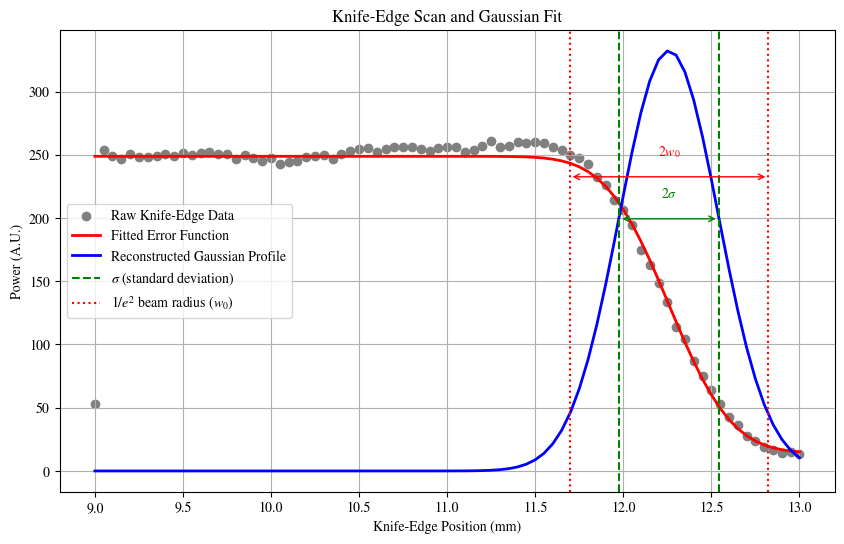

In [8]:
with open("D:/Aldric/Data/251027/28.5_THz_knifeEdge_1D.json", "r") as f:
    data_dict = js.load(f)
result = findBeamWidth(data_dict)
visualise_1D_gaussian_beam_profile(result)

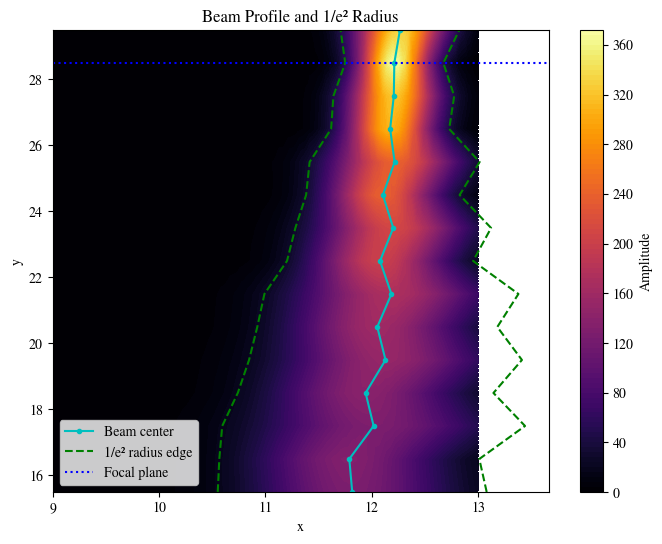

Fitted amplitude: 213.6242
Fitted center: 12.2130
Fitted Gaussian width (sigma): 0.2306
Fitted offset: 29.2678


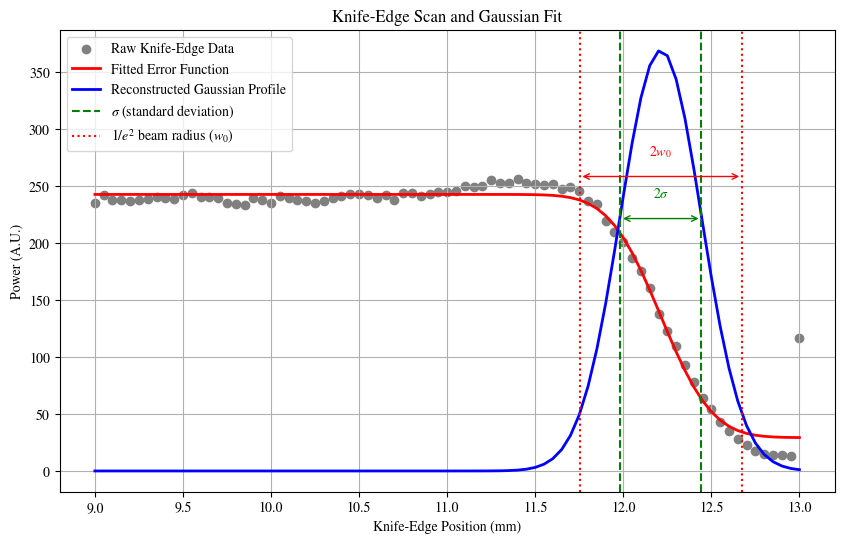

28.5

In [7]:
analyze_beam("D:/Aldric/Data/251027/THz_knifeEdge.json", plot=True, visualise_focal_1D = True)

# Typical dark THz setup tuning analysis
This workflow helps check the bandwidth and dynamic ranges of the SNR within the system to give you an idea if it is well tuned or not.

fft_E max at =  0.6686211130986529
20
Bandwidth lower limit =  0.134  THz
Bandwidth upper limit =  1.939  THz
Bandwidth =  1.805  THz
Balance_mean:  142.95928100668152


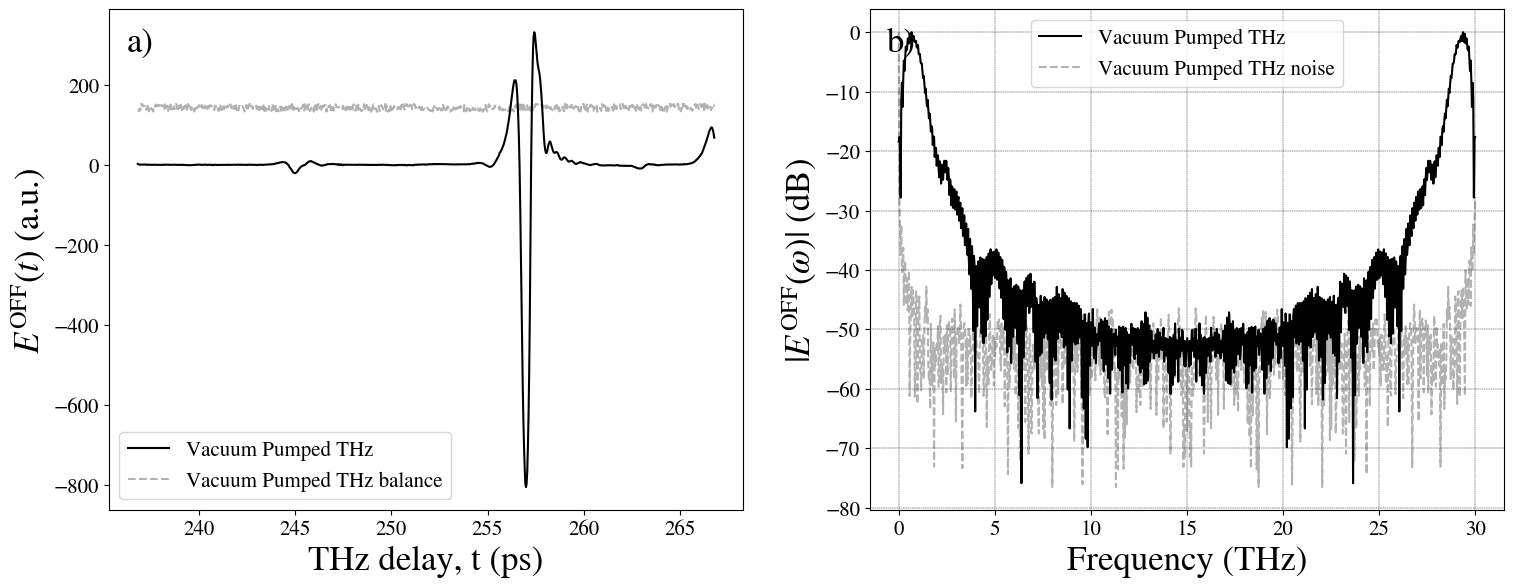

In [20]:
dataframe = generate_cleaned_up_dataframe("D:/Aldric/Anish's thin films/250930/1_reference_Dark THz.txt")
dataframe = dataframe
BW_lower_index, max_fft_E_off_index, BW_upper_index, bandwidth = extract_bandwidth(dataframe)
print("Balance_mean: ", np.mean(dataframe["D"]))
dark_spec_fig, dark_axs = plt.subplots(ncols=2,
                                        figsize=figure_size_2,
                                        gridspec_kw={'hspace': 0,
                                                    'wspace': 0.2})
dark_axs = plot_dark_spectrum(dark_axs,
                              dataframe,
                              label='Vacuum Pumped THz',
                              color='black',
                              legend=True,
                              plot_balance = True)

D:\Aldric\Data\251028\bandwidth_tuning\1_138.37999999999965_BW.txt
fft_E max at =  0.6779056956526351
9
Bandwidth lower limit =  0.0  THz
Bandwidth upper limit =  2.034  THz
Bandwidth =  2.034  THz
Balance_mean:  82.58298030316256


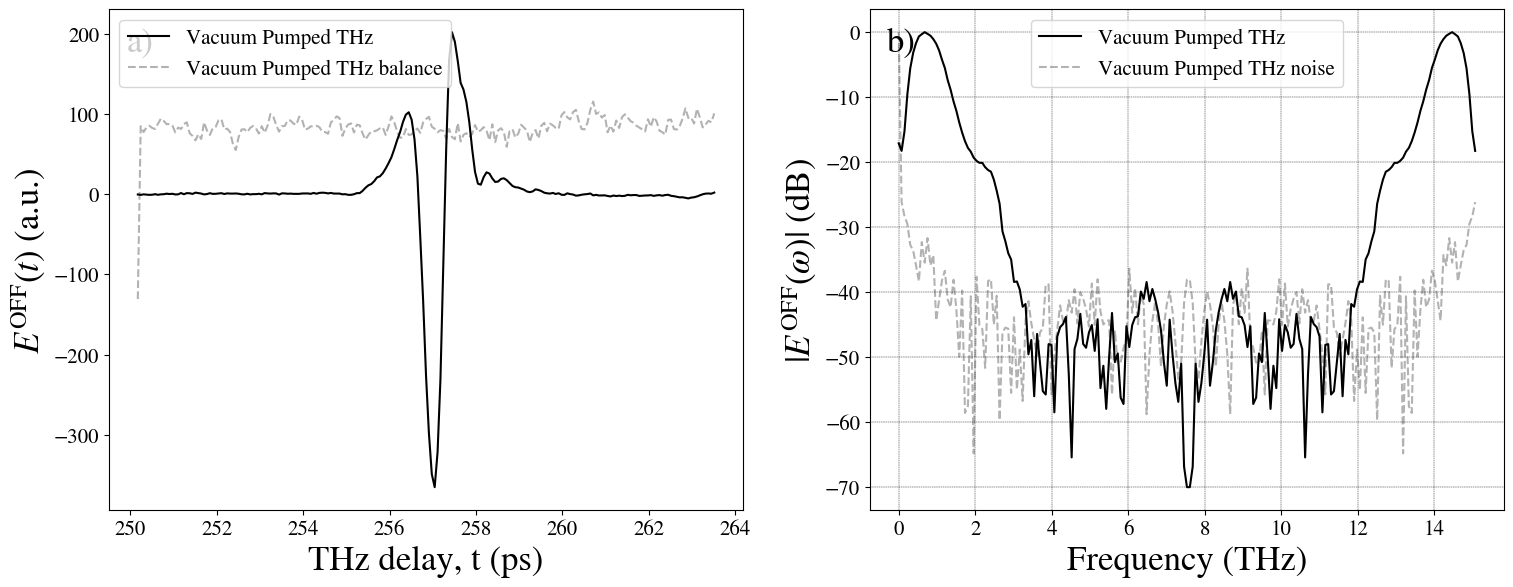

In [13]:
directory = Path("D:/Aldric/Data/251028/bandwidth_tuning")

try:
    # Loop through each file in the directory
    previous_bandwidth = 0
    max_bandwidth_file = ""
    for file in directory.iterdir():
        if file.is_file() and file.suffix == ".txt":  # Check if it's a file
            dataframe = generate_cleaned_up_dataframe(str(file))
            #dataframe = dataframe[1:]
            BW_lower_index, max_fft_E_off_index, BW_upper_index, bandwidth = extract_bandwidth(dataframe,
                                                                                                print_details=False)
            if bandwidth > previous_bandwidth:
                max_bandwidth_file = file
            previous_bandwidth = bandwidth
except FileNotFoundError:
    print(f"Error: The directory '{directory}' does not exist.")
except PermissionError:
    print(f"Error: Permission denied to access '{directory}'.")
print(max_bandwidth_file)
dataframe = generate_cleaned_up_dataframe(str(max_bandwidth_file))
BW_lower_index, max_fft_E_off_index, BW_upper_index, bandwidth = extract_bandwidth(dataframe)
print("Balance_mean: ", np.mean(dataframe["D"]))
dark_spec_fig, dark_axs = plt.subplots(ncols=2,
                                        figsize=figure_size_2,
                                        gridspec_kw={'hspace': 0,
                                                    'wspace': 0.2})
dark_axs = plot_dark_spectrum(dark_axs,
                              dataframe,
                              label='Vacuum Pumped THz',
                              color='black',
                              legend=True,
                              plot_balance = True)

In [12]:
dataframe = generate_cleaned_up_dataframe("D:/Aldric/Data/verification_of_per_step_recalibration/251017/" \
"1_reference_per_step_calibratton_Dark THz.txt", limits= [60, 399])
print(dataframe["Delay (mm)"][0])
BW_lower_index, max_fft_E_off_index, BW_upper_index, bandwidth = extract_bandwidth(dataframe)
print("Balance_mean: ", np.mean(dataframe["D"]))
dark_spec_fig, dark_axs = plt.subplots(ncols=2,
                                        figsize=figure_size_2,
                                        gridspec_kw={'hspace': 0,
                                                    'wspace': 0.2})
dark_axs = plot_dark_spectrum(dark_axs,
                              dataframe,
                              label='Vacuum Pumped THz',
                              color='black',
                              legend=True,
                              plot_balance = True)

FileNotFoundError: [Errno 2] No such file or directory: 'D:/Aldric/Data/verification_of_per_step_recalibration/251017/1_reference_per_step_calibratton_Dark THz.txt'

In [16]:
dataframe = generate_cleaned_up_dataframe("D:/Aldric/Data/verification_of_per_step_recalibration/251017/" \
"1_reference_per_step_calibratton_Dark THz.txt",  limits= [0, 460], zeropad=[36, 39.5, 5e-3])
dark_spec_fig, dark_axs = plt.subplots(ncols=2,
                                        figsize=figure_size_2,
                                        gridspec_kw={'hspace': 0,
                                                    'wspace': 0.2})
dark_axs = plot_dark_spectrum(dark_axs,
                              dataframe,
                              label='Vacuum Pumped THz',
                              color='black',
                              legend=True,
                              plot_balance = True)

FileNotFoundError: [Errno 2] No such file or directory: 'D:/Aldric/Data/verification_of_per_step_recalibration/251017/1_reference_per_step_calibratton_Dark THz.txt'

In [17]:
dataframe = generate_cleaned_up_dataframe("D:/Aldric/Data/verification_of_per_step_recalibration/251017/" \
"1_quartz_per_step_calibratton_Dark THz.txt", zeropad=[36, 39.5, 5e-3])
dark_spec_fig, dark_axs = plt.subplots(ncols=2,
                                        figsize=figure_size_2,
                                        gridspec_kw={'hspace': 0,
                                                    'wspace': 0.2})
dark_axs = plot_dark_spectrum(dark_axs,
                              dataframe,
                              label='Vacuum Pumped THz',
                              color='black',
                              legend=True,
                              plot_balance = True)

FileNotFoundError: [Errno 2] No such file or directory: 'D:/Aldric/Data/verification_of_per_step_recalibration/251017/1_quartz_per_step_calibratton_Dark THz.txt'

In [18]:
dataframe = generate_cleaned_up_dataframe("D:/Aldric/Data/verification_of_per_step_recalibration/251016/" \
"1_quartz_no_midscan_tuning_recalibrae_between_scans_Dark THz.txt", limits = [2, 399])
BW_lower_index, max_fft_E_off_index, BW_upper_index, bandwidth = extract_bandwidth(dataframe)
print("Balance_mean: ", np.mean(dataframe["D"]))
dark_spec_fig, dark_axs = plt.subplots(ncols=2,
                                        figsize=figure_size_2,
                                        gridspec_kw={'hspace': 0,
                                                    'wspace': 0.2})
dark_axs = plot_dark_spectrum(dark_axs,
                              dataframe,
                              label="THz",
                              color='black',
                              legend=True,
                              plot_balance = True)

FileNotFoundError: [Errno 2] No such file or directory: 'D:/Aldric/Data/verification_of_per_step_recalibration/251016/1_quartz_no_midscan_tuning_recalibrae_between_scans_Dark THz.txt'

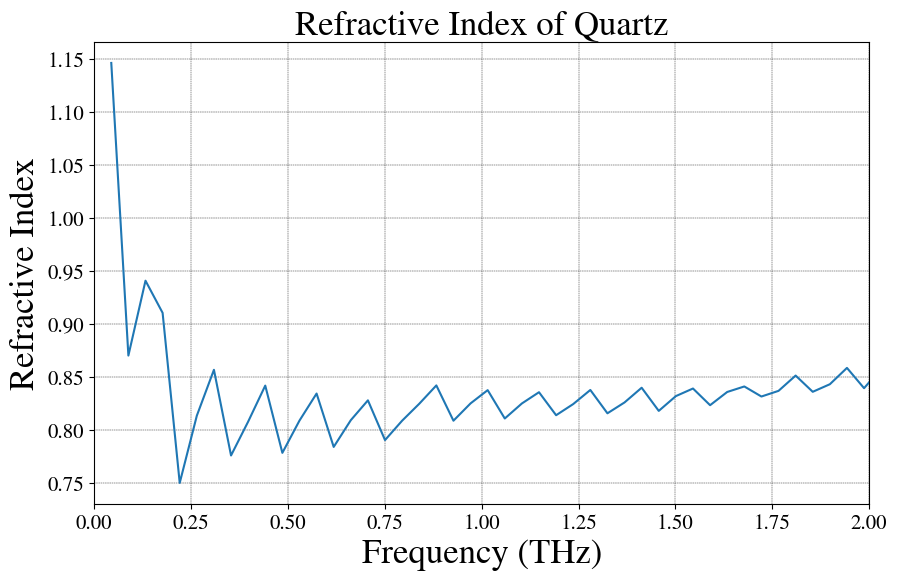

In [161]:
reference_dataframe = generate_cleaned_up_dataframe("D:/Aldric/Data/verification_of_per_step_recalibration/251016/" \
"1_reference_no_midscan_tuning_recalibrae_between_scans_Dark THz.txt",  limits= [0, 460], zeropad=[36, 39.4, 5e-3])
quartz_dataframe = generate_cleaned_up_dataframe("D:/Aldric/Data/verification_of_per_step_recalibration/251016/" \
"1_quartz_no_midscan_tuning_recalibrae_between_scans_Dark THz.txt", limits= [2, 399], zeropad=[36, 39.4, 5e-3])

transmission_function = quartz_dataframe['fft_E_off'] / reference_dataframe['fft_E_off']
phase = np.unwrap(np.angle(transmission_function)*2*np.pi)

refractive_index = 1 - 299792458*(phase) / \
(2*np.pi*2e-3*quartz_dataframe['Frequencies (Hz)'])

plt.figure(figsize=(10,6))
plt.plot(quartz_dataframe['Frequencies (Hz)']*1e-12, refractive_index)
plt.xlabel("Frequency (THz)", fontsize=fontsize)
plt.ylabel("Refractive Index", fontsize=fontsize)
plt.xlim(0,2)
#plt.ylim(1.5, 2.5)
plt.grid(color='black', which="both", linestyle='--',
         linewidth=0.3)
plt.title("Refractive Index of Quartz", fontsize=fontsize)
plt.tick_params(axis='both', which='major', labelsize=tick_fontsize)
plt.show()

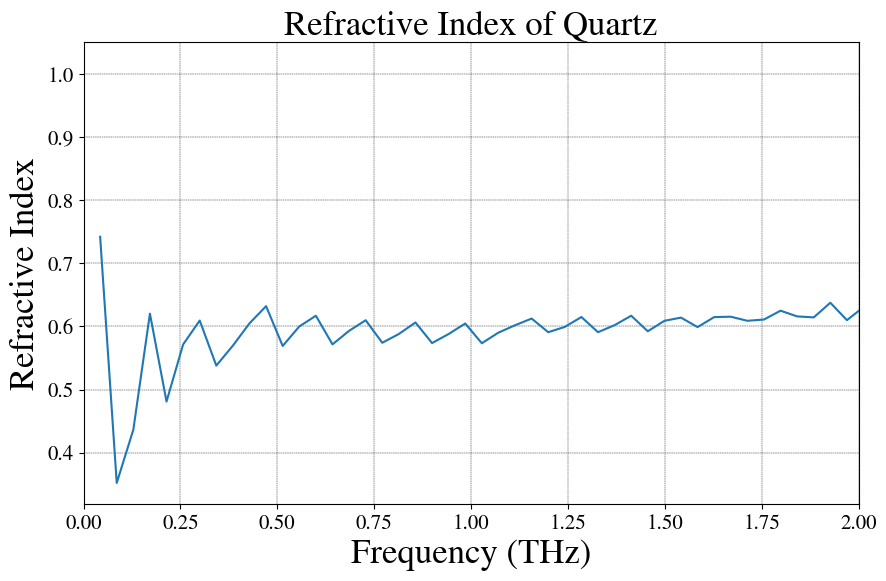

In [162]:
reference_dataframe = generate_cleaned_up_dataframe("D:/Aldric/Data/verification_of_per_step_recalibration/251016/" \
"1_reference_no_midscan_tuning_Dark THz.txt", limits= [0, 460], zeropad=[36, 39.5, 5e-3])
quartz_dataframe = generate_cleaned_up_dataframe("D:/Aldric/Data/verification_of_per_step_recalibration/251016/" \
"1_quartz_no_midscan_tuning_Dark THz.txt", limits= [2, 399], zeropad=[36, 39.5, 5e-3])

transmission_function = quartz_dataframe['fft_E_off'] / reference_dataframe['fft_E_off']
phase = np.unwrap(np.angle(transmission_function)*2*np.pi)

refractive_index = 1 - 299792458*(phase) / \
(2*np.pi*2e-3*quartz_dataframe['Frequencies (Hz)'])

plt.figure(figsize=(10,6))
plt.plot(quartz_dataframe['Frequencies (Hz)']*1e-12, refractive_index)
plt.xlabel("Frequency (THz)", fontsize=fontsize)
plt.ylabel("Refractive Index", fontsize=fontsize)
plt.xlim(0,2)
#plt.ylim(1.5, 2.5)
plt.grid(color='black', which="both", linestyle='--',
         linewidth=0.3)
plt.title("Refractive Index of Quartz", fontsize=fontsize)
plt.tick_params(axis='both', which='major', labelsize=tick_fontsize)
plt.show()

In [19]:
reference_dataframe = generate_cleaned_up_dataframe("D:/Aldric/Data/verification_of_per_step_recalibration/251017/" \
"1_reference_per_step_calibratton_Dark THz.txt",  limits= [0, 460], zeropad=[36, 39.5, 5e-3])
quartz_dataframe = generate_cleaned_up_dataframe("D:/Aldric/Data/verification_of_per_step_recalibration/251017/" \
"1_quartz_per_step_calibratton_Dark THz.txt", zeropad=[36, 39.5, 5e-3])

transmission_function = quartz_dataframe['fft_E_off'] / reference_dataframe['fft_E_off']
phase = np.unwrap(np.angle(transmission_function, deg=False))

refractive_index = 1 - 299792458*(phase) / \
(2*np.pi*2e-3*quartz_dataframe['Frequencies (Hz)'])

plt.figure(figsize=(10,6))
plt.plot(quartz_dataframe['Frequencies (Hz)']*1e-12, phase)
plt.xlabel("Frequency (THz)", fontsize=fontsize)
plt.ylabel("Refractive Index", fontsize=fontsize)
plt.xlim(0,5)
#plt.ylim(-2, 1)
plt.grid(color='black', which="both", linestyle='--',
         linewidth=0.3)
plt.title("Refractive Index of Quartz", fontsize=fontsize)
plt.tick_params(axis='both', which='major', labelsize=tick_fontsize)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(quartz_dataframe['Frequencies (Hz)']*1e-12, refractive_index)
plt.xlabel("Frequency (THz)", fontsize=fontsize)
plt.ylabel("Refractive Index", fontsize=fontsize)
plt.xlim(0,5)
#plt.ylim(-2, 1)
plt.grid(color='black', which="both", linestyle='--',
         linewidth=0.3)
plt.title("Refractive Index of Quartz", fontsize=fontsize)
plt.tick_params(axis='both', which='major', labelsize=tick_fontsize)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'D:/Aldric/Data/verification_of_per_step_recalibration/251017/1_reference_per_step_calibratton_Dark THz.txt'